In [3]:
import pandas as pd
import numpy as np
import json
import matplotlib.pyplot as plt
import seaborn as sns
from pyspark.sql import SparkSession
from pyspark.sql.functions import col, when, coalesce, lit
from pyspark.ml import PipelineModel
from pyspark.ml.evaluation import MulticlassClassificationEvaluator

spark = (SparkSession.builder
    .appName("AmazonReviewsEvaluation")
    .config("spark.driver.memory", "4g")
    .config("spark.sql.shuffle.partitions", "8")
    .getOrCreate())
spark.sparkContext.setLogLevel("ERROR")
print("✅ Spark démarré")

✅ Spark démarré


In [4]:
# Charger test set
test_df = spark.read.csv("../data/test_set.csv",
                          header=True, inferSchema=True,
                          quote='"', escape='"')

test_df = test_df.withColumn("sentiment", col("sentiment").cast("integer"))
test_df = test_df.filter(
    col("cleaned").isNotNull() &
    (col("cleaned") != "") &
    col("sentiment").isNotNull()
)
test_df = test_df.withColumn("cleaned", coalesce(col("cleaned"), lit("")))

print(f"Test set: {test_df.count():,} reviews")
test_df.groupBy("sentiment").count().orderBy("sentiment").show()

# Charger le meilleur modèle
model = PipelineModel.load("../models/best_model")
print("✅ Modèle chargé")

Test set: 56,846 reviews


+---------+-----+
|sentiment|count|
+---------+-----+
|        0| 8204|
|        1| 4264|
|        2|44378|
+---------+-----+



✅ Modèle chargé


In [5]:
print("Prédictions sur test set...")
predictions = model.transform(test_df)

# Ajouter label texte
predictions = predictions.withColumn("sentiment_label",
    when(col("prediction") == 0, "negative")
    .when(col("prediction") == 1, "neutral")
    .otherwise("positive"))

predictions = predictions.withColumn("true_label",
    when(col("sentiment") == 0, "negative")
    .when(col("sentiment") == 1, "neutral")
    .otherwise("positive"))

print("Sample prédictions:")
predictions.select("cleaned", "sentiment", "prediction", 
                   "sentiment_label", "probability").show(5, truncate=40)

Prédictions sur test set...
Sample prédictions:
+----------------------------------------+---------+----------+---------------+----------------------------------------+
|                                 cleaned|sentiment|prediction|sentiment_label|                             probability|
+----------------------------------------+---------+----------+---------------+----------------------------------------+
|delicious sweet tea great price pregn...|        2|       2.0|       positive|[0.007726843835458997,0.0121544642917...|
|super cocoa according cook illustrate...|        2|       2.0|       positive|[0.3266493499467034,0.288484251403859...|
|lightly salted heavily delicious best...|        2|       2.0|       positive|[0.04455220752545925,0.02196340310398...|
|love stuff bag lot stuff honestly one...|        2|       2.0|       positive|[0.11395840017556673,0.11954899924437...|
|lapsang tea like lapsang souchong tea...|        1|       1.0|        neutral|[0.3028399714775803,0.4483

In [6]:
# F1, Accuracy, Precision, Recall
evaluator_f1  = MulticlassClassificationEvaluator(
    labelCol="sentiment", predictionCol="prediction", metricName="f1")
evaluator_acc = MulticlassClassificationEvaluator(
    labelCol="sentiment", predictionCol="prediction", metricName="accuracy")
evaluator_p   = MulticlassClassificationEvaluator(
    labelCol="sentiment", predictionCol="prediction", metricName="weightedPrecision")
evaluator_r   = MulticlassClassificationEvaluator(
    labelCol="sentiment", predictionCol="prediction", metricName="weightedRecall")

f1  = evaluator_f1.evaluate(predictions)
acc = evaluator_acc.evaluate(predictions)
p   = evaluator_p.evaluate(predictions)
r   = evaluator_r.evaluate(predictions)

print("="*45)
print("  RÉSULTATS FINAUX SUR TEST SET")
print("="*45)
print(f"  F1-macro  : {f1:.4f}  ({f1*100:.1f}%)")
print(f"  Accuracy  : {acc:.4f}  ({acc*100:.1f}%)")
print(f"  Precision : {p:.4f}  ({p*100:.1f}%)")
print(f"  Recall    : {r:.4f}  ({r*100:.1f}%)")
print("="*45)

# Sauvegarder dans metadata
with open("../models/metadata.json", "r") as f:
    metadata = json.load(f)

metadata["f1_test"]  = f1
metadata["acc_test"] = acc
metadata["precision_test"] = p
metadata["recall_test"] = r

with open("../models/metadata.json", "w") as f:
    json.dump(metadata, f, indent=2)

print("\n✅ Métriques sauvegardées")

  RÉSULTATS FINAUX SUR TEST SET
  F1-macro  : 0.8320  (83.2%)
  Accuracy  : 0.8077  (80.8%)
  Precision : 0.8750  (87.5%)
  Recall    : 0.8077  (80.8%)

✅ Métriques sauvegardées


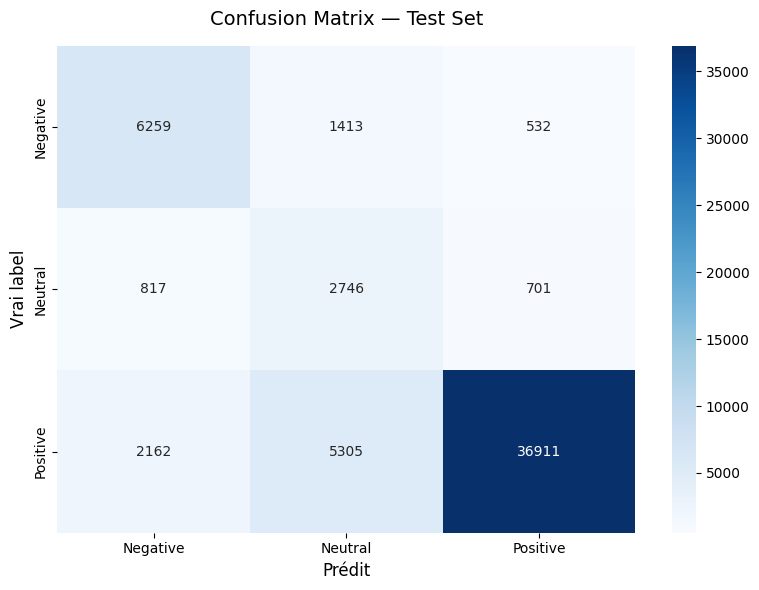


Classification Report:
              precision    recall  f1-score   support

    Negative       0.68      0.76      0.72      8204
     Neutral       0.29      0.64      0.40      4264
    Positive       0.97      0.83      0.89     44378

    accuracy                           0.81     56846
   macro avg       0.65      0.75      0.67     56846
weighted avg       0.87      0.81      0.83     56846



In [7]:
# Collecter les prédictions
preds_pd = predictions.select("sentiment", "prediction").toPandas()

from sklearn.metrics import confusion_matrix, classification_report

cm = confusion_matrix(preds_pd["sentiment"], preds_pd["prediction"])
labels = ["Negative", "Neutral", "Positive"]

# Plot
fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=labels, yticklabels=labels, ax=ax)
ax.set_title("Confusion Matrix — Test Set", fontsize=14, pad=15)
ax.set_ylabel("Vrai label", fontsize=12)
ax.set_xlabel("Prédit", fontsize=12)

plt.tight_layout()
plt.savefig("../docs/confusion_matrix.png", dpi=150, bbox_inches='tight')
plt.show()

# Classification report
print("\nClassification Report:")
print(classification_report(preds_pd["sentiment"], preds_pd["prediction"],
                             target_names=labels))

In [8]:
# Sauvegarder les prédictions pour analyse
preds_full = predictions.select(
    "Id", "ProductId", "UserId", "Time",
    "Summary", "Text", "sentiment", 
    "prediction", "sentiment_label"
).toPandas()

preds_full.to_csv("../data/test_predictions.csv", index=False)
print(f"✅ {len(preds_full):,} prédictions sauvegardées")
print(f"   ../data/test_predictions.csv")

# Stats rapides
print(f"\nDistribution prédictions:")
print(preds_full['sentiment_label'].value_counts())

✅ 56,846 prédictions sauvegardées
   ../data/test_predictions.csv

Distribution prédictions:
sentiment_label
positive    38144
neutral      9464
negative     9238
Name: count, dtype: int64
